# Performance Analytics

## Bluestock Mutual Fund Analysis

### Objectives

- Compute Daily Returns
- Compute CAGR (1Y, 3Y, 5Y)
- Compute Sharpe Ratio
- Compute Sortino Ratio
- Compute Alpha & Beta
- Compute Maximum Drawdown
- Create Fund Scorecard
- Benchmark Comparison

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

from scipy.stats import linregress

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

fund = pd.read_csv("../data/raw/01_fund_master.csv")

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [4]:
print(benchmark.shape)
print(benchmark.columns)
benchmark.head()

(8050, 3)
Index(['date', 'index_name', 'close_value'], dtype='object')


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


# 2. CAGR (1 Year, 3 Year, 5 Year)

Compound Annual Growth Rate (CAGR) measures the annualized return of each mutual fund over different investment horizons.

In [5]:
# Ensure date is datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

In [6]:
def calculate_cagr(df, years):
    result = []

    for amfi, group in df.groupby("amfi_code"):

        group = group.sort_values("date")

        end_date = group["date"].max()
        start_date = end_date - pd.DateOffset(years=years)

        period = group[group["date"] >= start_date]

        if len(period) < 2:
            continue

        nav_start = period.iloc[0]["nav"]
        nav_end = period.iloc[-1]["nav"]

        cagr = ((nav_end / nav_start) ** (1 / years)) - 1

        result.append({
            "amfi_code": amfi,
            f"CAGR_{years}Y": cagr
        })

    return pd.DataFrame(result)

In [7]:
cagr1 = calculate_cagr(nav, 1)
cagr3 = calculate_cagr(nav, 3)
cagr5 = calculate_cagr(nav, 5)

In [8]:
cagr = cagr1.merge(cagr3, on="amfi_code", how="outer")

cagr = cagr.merge(cagr5, on="amfi_code", how="outer")

cagr.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [9]:
cagr.to_csv(
    "../reports/cagr_comparison.csv",
    index=False
)

print("CAGR Table Saved")

CAGR Table Saved


# 3. Sharpe Ratio

In [11]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav'], dtype='object')


In [12]:
# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort
nav = nav.sort_values(["amfi_code", "date"])

# Compute daily returns
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print(nav.head())

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [13]:
print(nav.columns)

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')


In [14]:
risk_free = 0.065

sharpe = []

for amfi, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 10:
        continue

    sharpe_ratio = (
        (returns.mean() - risk_free/252)
        / returns.std()
    ) * np.sqrt(252)

    sharpe.append({
        "amfi_code": amfi,
        "Sharpe_Ratio": sharpe_ratio
    })

sharpe = pd.DataFrame(sharpe)

sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head()

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [15]:
print(nav.columns)
print(nav.head())

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='object')
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210


In [16]:
risk_free = 0.065

sharpe = []

for amfi, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 10:
        continue

    sharpe_ratio = (
        (returns.mean() - risk_free/252)
        / returns.std()
    ) * np.sqrt(252)

    sharpe.append({
        "amfi_code": amfi,
        "Sharpe_Ratio": sharpe_ratio
    })

sharpe = pd.DataFrame(sharpe)

sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe.head()

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


# 4. Sortino Ratio

The Sortino Ratio measures risk-adjusted returns using only downside volatility.

In [17]:
sortino = []

for amfi, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 10:
        continue

    # Downside returns only
    downside = returns[returns < 0]

    if len(downside) == 0:
        continue

    downside_std = downside.std()

    sortino_ratio = (
        (returns.mean() - risk_free / 252)
        / downside_std
    ) * np.sqrt(252)

    sortino.append({
        "amfi_code": amfi,
        "Sortino_Ratio": sortino_ratio
    })

sortino = pd.DataFrame(sortino)

sortino = sortino.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino.head()

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


# 5. Alpha and Beta

In [18]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
             .pct_change()
)

In [19]:
alpha_beta = []

# Use NIFTY100 benchmark
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
][["date", "benchmark_return"]]

for amfi, group in nav.groupby("amfi_code"):

    temp = group[["date", "daily_return"]].merge(
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(temp) < 30:
        continue

    beta, alpha, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": amfi,
        "Alpha": alpha * 252,
        "Beta": beta
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [20]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

# 6. Maximum Drawdown

Maximum Drawdown measures the largest decline from a fund's peak NAV before it recovered.

In [21]:
drawdown = []

for amfi, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    running_max = group["nav"].cummax()

    dd = (group["nav"] / running_max) - 1

    min_dd = dd.min()

    worst_date = group.loc[dd.idxmin(), "date"]

    drawdown.append({
        "amfi_code": amfi,
        "Max_Drawdown": min_dd,
        "Worst_Date": worst_date
    })

drawdown = pd.DataFrame(drawdown)

drawdown.head()

,amfi_code,Max_Drawdown,Worst_Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [23]:
print(performance.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='object')


In [25]:
scorecard = (
    cagr.merge(sharpe, on="amfi_code")
        .merge(alpha_beta, on="amfi_code")
        .merge(drawdown, on="amfi_code")
        .merge(
            performance[["amfi_code", "expense_ratio_pct"]],
            on="amfi_code"
        )
)

In [26]:
# Ranking Metrics

scorecard["ReturnRank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["SharpeRank"] = scorecard["Sharpe_Ratio"].rank(ascending=False)

scorecard["AlphaRank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["ExpenseRank"] = scorecard["expense_ratio_pct"].rank()

scorecard["DrawdownRank"] = scorecard["Max_Drawdown"].rank(ascending=False)

scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Worst_Date,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank
0,100016,-0.022243,0.012926,0.023168,-0.201517,0.037476,-0.058268,-0.247344,2022-09-15,1.55,35.0,35.0,39.0,32.0,34.0
1,100025,0.037050,0.039164,0.039127,-0.567095,0.042818,0.001158,-0.043083,2023-07-28,0.56,34.0,39.0,38.0,2.0,4.0
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,2022-05-12,1.38,4.0,7.0,6.0,17.0,20.0
3,101206,0.479241,0.289677,0.204427,1.027213,0.213998,0.021086,-0.112916,2023-07-05,1.60,9.0,9.0,12.0,36.5,9.0
4,101207,-0.239860,-0.041524,0.069533,0.162661,0.108971,-0.065289,-0.354469,2026-05-11,1.53,39.0,28.0,27.0,28.5,38.0


In [27]:
scorecard["Fund_Score"] = (
      30 * (1 / scorecard["ReturnRank"])
    + 25 * (1 / scorecard["SharpeRank"])
    + 20 * (1 / scorecard["AlphaRank"])
    + 15 * (1 / scorecard["ExpenseRank"])
    + 10 * (1 / scorecard["DrawdownRank"])
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Worst_Date,expense_ratio_pct,ReturnRank,SharpeRank,AlphaRank,ExpenseRank,DrawdownRank,Fund_Score
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,2023-10-20,1.46,2.0,1.0,7.0,23.0,8.0,44.759317
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,2022-08-11,1.38,1.0,11.0,9.0,17.0,28.0,35.734445
21,119598,0.827761,0.266699,0.280332,0.945308,0.303370,-0.023196,-0.287060,2025-05-14,1.43,12.0,14.0,1.0,21.0,36.0,25.277778
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,2022-04-13,1.45,7.0,2.0,5.0,22.0,13.0,22.236763
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,2025-01-23,1.36,5.0,5.0,3.0,15.0,25.0,19.066667
13,118636,0.104549,0.040622,0.046639,-0.356630,0.050748,0.001257,-0.083164,2024-02-09,0.55,33.0,38.0,35.0,1.0,6.0,18.805081
36,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,2023-10-20,1.60,8.0,3.0,4.0,36.5,21.0,17.970483
24,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,2023-05-30,0.80,3.0,10.0,13.0,12.0,12.0,16.121795
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,2022-05-12,1.38,4.0,7.0,6.0,17.0,20.0,15.787115
39,149324,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,-0.311719,2025-01-03,1.52,10.0,13.0,2.0,26.5,37.0,15.759385


In [28]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved Successfully")

Fund Scorecard Saved Successfully


In [29]:
print(benchmark["index_name"].unique())

['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [30]:
# Clean benchmark names
benchmark["index_name"] = (
    benchmark["index_name"]
    .astype(str)
    .str.strip()
    .str.replace("Ø", "0", regex=False)
)

print(benchmark["index_name"].unique())

['BSE_SMALLCAP' 'CRISIL_GILT' 'CRISIL_LIQUID' 'NIFTY100' 'NIFTY50'
 'NIFTY500' 'NIFTY_MIDCAP150']


In [31]:
nifty = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty["benchmark_return"] = nifty["close_value"].pct_change()

print(nifty.head())

           date index_name  close_value  benchmark_return
1150 2022-01-03   NIFTY100     17778.24               NaN
1151 2022-01-04   NIFTY100     17537.52         -0.013540
1152 2022-01-05   NIFTY100     17607.73          0.004003
1153 2022-01-06   NIFTY100     17556.05         -0.002935
1154 2022-01-07   NIFTY100     17664.02          0.006150


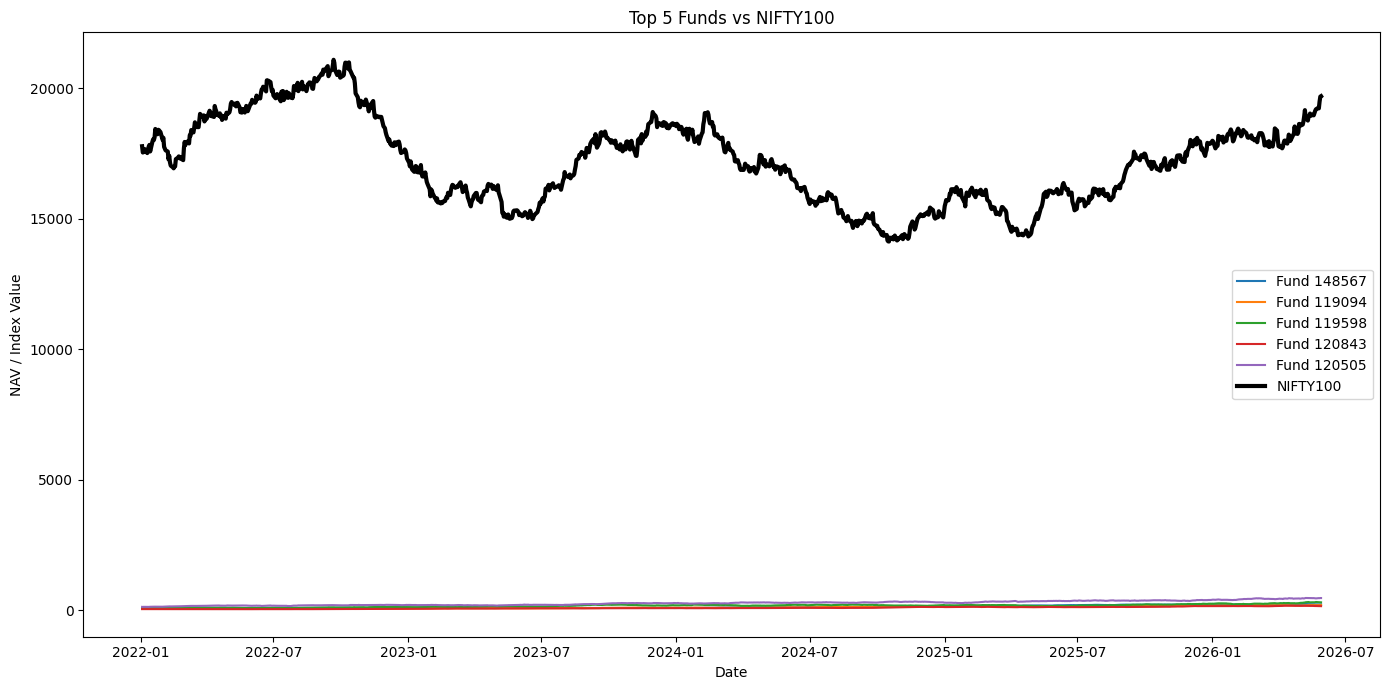

In [32]:
plt.figure(figsize=(14,7))

# Plot Top 5 Funds
top5 = scorecard.head(5)["amfi_code"]

for code in top5:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=f"Fund {code}")

# Plot NIFTY100
plt.plot(
    nifty["date"],
    nifty["close_value"],
    color="black",
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300
)

plt.show()

In [33]:
tracking = []

for code in top5:

    temp = nav[nav["amfi_code"] == code][["date", "daily_return"]]

    merged = temp.merge(
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 10:
        continue

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking.append({
        "amfi_code": code,
        "Tracking_Error": tracking_error
    })

tracking = pd.DataFrame(tracking)

tracking

,amfi_code,Tracking_Error
0,148567,0.189664
1,119094,0.237652
2,119598,0.283881
3,120843,0.206425
4,120505,0.231968
